# SARIMAX — Predicción de Tráfico M30
> Modelo estadístico SARIMAX con estacionalidad diaria (s=24). Configuración: 48h y 168h de ventana histórica → horizontes 1h, 24h, 168h.
>
> **Estilos:** Ver `documents/Estilos tfm.MD`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings("ignore")

# ---------------------------------------------------------------------------
# CARGA DE DATOS — splits cronológicos (sin solapamiento)
# ---------------------------------------------------------------------------
ruta_train = '../../data/processed/Split_Datasets/data_train_clean.csv'
ruta_val   = '../../data/processed/Split_Datasets/data_val_clean.csv'
ruta_test  = '../../data/processed/Split_Datasets/data_test_clean.csv'

def preparar_indice_temporal(df):
    """Convierte 'fecha' en índice datetime con frecuencia horaria estricta."""
    df['fecha'] = pd.to_datetime(df['fecha'])
    df.set_index('fecha', inplace=True)
    df.sort_index(inplace=True)
    df = df.asfreq('h')
    return df

df_train = pd.read_csv(ruta_train, parse_dates=['fecha'], index_col='fecha')
df_val   = pd.read_csv(ruta_val,   parse_dates=['fecha'], index_col='fecha')
df_test  = pd.read_csv(ruta_test,  parse_dates=['fecha'], index_col='fecha')

df_train.sort_index(inplace=True)
df_val.sort_index(inplace=True)
df_test.sort_index(inplace=True)

# ---------------------------------------------------------------------------
# Definición de columnas
# ---------------------------------------------------------------------------
cols_endogenas  = [col for col in df_train.columns
                   if 'intensidad' in col or 'ocupacion' in col or 'vmed' in col]
cols_exogenas   = ['hora', 'dia_semana', 'mes', 'es_finde']
cols_intensidad = [col for col in cols_endogenas if 'intensidad' in col]
sensores        = ['Sensor 3820', 'Sensor 6642', 'Sensor 6676', 'Sensor 6782']
sensor_ids      = ['3820', '6642', '6676', '6782']

print("--- ESTRUCTURA DE DATOS ---")
print(f"Train : {df_train.shape} | {df_train.index.min()} → {df_train.index.max()}")
print(f"Val   : {df_val.shape}   | {df_val.index.min()} → {df_val.index.max()}")
print(f"Test  : {df_test.shape}  | {df_test.index.min()} → {df_test.index.max()}")
print(f"\nVariables objetivo (intensidad): {cols_intensidad}")


--- ESTRUCTURA DE DATOS ---
Train : (16080, 16) | 2024-01-01 00:00:00 → 2025-10-31 23:00:00
Val   : (1464, 16)   | 2025-11-01 00:00:00 → 2025-12-31 23:00:00
Test  : (1416, 16)  | 2026-01-01 00:00:00 → 2026-02-28 23:00:00

Variables objetivo (intensidad): ['intensidad_3820', 'intensidad_6642', 'intensidad_6676', 'intensidad_6782']


## 2. Imputación y Variables de Calendario

In [2]:
def limpiar_nulos(df, cols_endo):
    """Imputa nulos por interpolación lineal y reconstruye variables de calendario."""
    df[cols_endo] = df[cols_endo].interpolate(method='linear', limit_direction='both')
    df['hora']       = df.index.hour
    df['dia_semana'] = df.index.dayofweek
    df['mes']        = df.index.month
    df['es_finde']   = (df['dia_semana'] >= 5).astype(int)
    return df

df_train = limpiar_nulos(df_train, cols_endogenas)
df_val   = limpiar_nulos(df_val,   cols_endogenas)
df_test  = limpiar_nulos(df_test,  cols_endogenas)

nulos_total = (df_train.isnull().sum().sum() +
               df_val.isnull().sum().sum()   +
               df_test.isnull().sum().sum())
print(f"✅ Nulos totales tras imputación: {nulos_total}")


✅ Nulos totales tras imputación: 0


## 3. Test de Estacionariedad (ADF)

In [3]:
from statsmodels.tsa.stattools import adfuller

def test_adf(df, columnas):
    """Test de Dickey-Fuller Aumentado para cada columna."""
    print("--- TEST ADF (Dickey-Fuller Aumentado) ---")
    print("H0: La serie NO es estacionaria | H1: La serie ES estacionaria (p < 0.05)\n")
    no_estacionarias = []
    for col in columnas:
        resultado = adfuller(df[col].dropna(), autolag='AIC')
        p = resultado[1]
        estado = "✅ Estacionaria" if p < 0.05 else "❌ No estacionaria"
        if p >= 0.05:
            no_estacionarias.append(col)
        print(f"  {col:<30} p-valor: {p:.4f}  →  {estado}")
    print(f"\nResumen: {len(no_estacionarias)} series no estacionarias de {len(columnas)}")
    return no_estacionarias

series_no_estacionarias = test_adf(df_train, cols_intensidad)


--- TEST ADF (Dickey-Fuller Aumentado) ---
H0: La serie NO es estacionaria | H1: La serie ES estacionaria (p < 0.05)

  intensidad_3820                p-valor: 0.0000  →  ✅ Estacionaria
  intensidad_6642                p-valor: 0.0000  →  ✅ Estacionaria
  intensidad_6676                p-valor: 0.0000  →  ✅ Estacionaria
  intensidad_6782                p-valor: 0.0000  →  ✅ Estacionaria

Resumen: 0 series no estacionarias de 4


## 4. Entrenamiento SARIMAX — Dos configuraciones de lag (48h y 168h)

Se entrena un modelo SARIMAX independiente por sensor y por configuración de lag.
Order: `(2,0,1)` | Seasonal order: `(1,0,1,24)` (estacionalidad diaria).

In [4]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

ORDER          = (2, 0, 1)      # (p, d, q)
SEASONAL_ORDER = (1, 0, 1, 24)  # (P, D, Q, s) — estacionalidad diaria

lags_a_evaluar    = [48, 168]
horizontes_a_eval = [1, 24, 168]

modelos_por_lag = {}  # { lag: { col: modelo_fitted } }

for lag in lags_a_evaluar:
    print(f"\n{'='*60}")
    print(f"  ENTRENANDO SARIMAX con lag={lag}h (histórico de entrada)")
    print(f"{'='*60}")
    modelos_sarimax = {}
    # Para SARIMAX el lag se usará en la predicción iterativa (ventana deslizante)
    for col in cols_intensidad:
        print(f"  ⏳ Ajustando SARIMAX para: {col} ...")
        try:
            modelo = SARIMAX(
                endog=df_train[col],
                exog=df_train[cols_exogenas],
                order=ORDER,
                seasonal_order=SEASONAL_ORDER,
                enforce_stationarity=False,
                enforce_invertibility=False
            )
            resultado = modelo.fit(disp=False)
            modelos_sarimax[col] = resultado
            print(f"    ✅ {col} → AIC: {resultado.aic:.2f} | BIC: {resultado.bic:.2f}")
        except Exception as e:
            print(f"    ❌ {col} → ERROR: {e}")
    modelos_por_lag[lag] = modelos_sarimax
    print(f"  Modelos entrenados para lag={lag}h: {len(modelos_sarimax)}/{len(cols_intensidad)}")



  ENTRENANDO SARIMAX con lag=48h (histórico de entrada)
  ⏳ Ajustando SARIMAX para: intensidad_3820 ...


c:\Users\cromi\Desktop\TFM GitHub\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
c:\Users\cromi\Desktop\TFM GitHub\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)


    ✅ intensidad_3820 → AIC: 252430.46 | BIC: 252507.30
  ⏳ Ajustando SARIMAX para: intensidad_6642 ...


c:\Users\cromi\Desktop\TFM GitHub\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
c:\Users\cromi\Desktop\TFM GitHub\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
c:\Users\cromi\Desktop\TFM GitHub\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


    ✅ intensidad_6642 → AIC: 255909.58 | BIC: 255986.41
  ⏳ Ajustando SARIMAX para: intensidad_6676 ...


...

    ✅ intensidad_6642 → AIC: 255909.58 | BIC: 255986.41
  ⏳ Ajustando SARIMAX para: intensidad_6676 ...


c:\Users\cromi\Desktop\TFM GitHub\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
c:\Users\cromi\Desktop\TFM GitHub\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
c:\Users\cromi\Desktop\TFM GitHub\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


    ✅ intensidad_6676 → AIC: 256744.02 | BIC: 256820.86
  ⏳ Ajustando SARIMAX para: intensidad_6782 ...


c:\Users\cromi\Desktop\TFM GitHub\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
c:\Users\cromi\Desktop\TFM GitHub\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
c:\Users\cromi\Desktop\TFM GitHub\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


    ✅ intensidad_6782 → AIC: 244425.33 | BIC: 244502.16
  Modelos entrenados para lag=168h: 4/4


## 5. Predicción sobre Validación

In [8]:
# ---------------------------------------------------------------------------
# 5. FUNCIONES DE PREDICCIÓN ROLLING FORECAST (VERSIÓN SÚPER OPTIMIZADA)
# ---------------------------------------------------------------------------
import numpy as np
import pandas as pd

historico_base_df = pd.concat([df_train, df_val])

def rolling_forecast_sarimax(modelos, historico_df, df_futuro, cols_exog, cols_obj, horizonte):
    reales = []
    preds = []
    n_test = len(df_futuro)
    
    print(f"    ⚡ Iniciando Rolling Forecast Optimizado (H={horizonte})...")
    
    for i in range(0, n_test - horizonte + 1, horizonte):
        
        real_window = df_futuro[cols_obj].iloc[i:i+horizonte].values
        reales.append(real_window)
        
        # OBTENEMOS SOLO LAS ÚLTIMAS 504 HORAS (3 SEMANAS) PARA EL CONTEXTO
        # Esto reduce el tiempo de cómputo de 80 minutos a apenas 2 o 3 minutos
        df_hasta_i = pd.concat([historico_df, df_futuro.iloc[:i]]).tail(504)
        exog_future = df_futuro[cols_exog].iloc[i:i+horizonte]
        
        pred_sensores = []
        
        for col in cols_obj:
            modelo_original = modelos[col]
            
            # El apply ahora solo procesa 504 filas en lugar de miles
            modelo_actualizado = modelo_original.apply(
                endog=df_hasta_i[col], 
                exog=df_hasta_i[cols_exog], 
                refit=False
            )
            
            pred = modelo_actualizado.forecast(steps=horizonte, exog=exog_future)
            pred_sensores.append(pred.values)
            
        preds.append(np.column_stack(pred_sensores))
        
        if i > 0 and i % (horizonte * 50) == 0:
            print(f"       ... instante {i}/{n_test} procesado.")
            
    return np.vstack(reales), np.vstack(preds)

print("✅ Función de Rolling Forecast (Optimizada) compilada correctamente.")

✅ Función de Rolling Forecast (Optimizada) compilada correctamente.


## 6. Evaluación sobre TEST y Tabla Resumen de Métricas

In [9]:
# ---------------------------------------------------------------------------
# 6. EVALUACIÓN SOBRE TEST Y TABLA RESUMEN (Modificado para Rolling Forecast)
# ---------------------------------------------------------------------------
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings

# --- BLOQUEO DE ALERTAS DE STATSMODELS ---
warnings.filterwarnings("ignore", module="statsmodels")
warnings.filterwarnings("ignore", message="No frequency information was provided")

# 1. ACTUALIZAMOS LA FUNCIÓN DE MÉTRICAS
def calcular_metricas_robustas(y_real, y_pred):
    resultados = {}
    for j, sensor in enumerate(sensores):
        real_j = y_real[:, j]
        pred_j = y_pred[:, j]
        
        mask = ~np.isnan(real_j) & ~np.isnan(pred_j)
        rmse = np.sqrt(mean_squared_error(real_j[mask], pred_j[mask]))
        mae  = mean_absolute_error(real_j[mask], pred_j[mask])
        r2   = r2_score(real_j[mask], pred_j[mask])
        
        resultados[sensor] = {'RMSE': rmse, 'MAE': mae, 'R²': r2}
    return resultados

def imprimir_tabla(resultados_test_lag, nombre_modelo):
    horizontes_nombres = {1: '1 HORA', 24: '24 HORAS', 168: '168 HORAS'}
    for horizonte in [1, 24, 168]:
        nombre_h = horizontes_nombres[horizonte]
        print(f"\n{'='*58}")
        print(f"  HORIZONTE: {nombre_h} — {nombre_modelo}")
        print(f"{'='*58}")
        print(f"  {'Sensor':<14} {'RMSE':>10} {'MAE':>10} {'R²':>10}")
        print(f"  {'-'*44}")
        rmse_vals, mae_vals, r2_vals = [], [], []
        for sensor in sensores:
            m = resultados_test_lag[horizonte][sensor]
            print(f"  {sensor:<14} {m['RMSE']:>10.2f} {m['MAE']:>10.2f} {m['R²']:>10.4f}")
            rmse_vals.append(m['RMSE'])
            mae_vals.append(m['MAE'])
            r2_vals.append(m['R²'])
        print(f"  {'-'*44}")
        print(f"  {'PROMEDIO':<14} "
              f"{sum(rmse_vals)/len(rmse_vals):>10.2f} "
              f"{sum(mae_vals)/len(mae_vals):>10.2f} "
              f"{sum(r2_vals)/len(r2_vals):>10.4f}")

# 2. BUCLE DE EJECUCIÓN PRINCIPAL
print("--- INICIANDO ROLLING FORECAST SOBRE TEST ---")
print("⚠️  Aviso: Este proceso iterará por todo el Test. Relájate, tomará unos minutos.")

resultados_test = {} 

for lag in lags_a_evaluar:
    print(f"\n{'*'*60}")
    print(f"  EVALUANDO SARIMAX con lag={lag}h")
    print(f"{'*'*60}")
    
    modelos_lag = modelos_por_lag[lag]
    
    for horizonte in horizontes_a_eval:
        y_real, y_pred = rolling_forecast_sarimax(
            modelos=modelos_lag,
            historico_df=historico_base_df,
            df_futuro=df_test,
            cols_exog=cols_exogenas,
            cols_obj=cols_intensidad,
            horizonte=horizonte
        )
        
        metricas = calcular_metricas_robustas(y_real, y_pred)
        resultados_test[(lag, horizonte)] = metricas
        print(f"  ✅ SARIMAX-{lag}h → {horizonte}h evaluado. Dimensiones analizadas: {y_real.shape}\n")

# 3. IMPRESIÓN DE TABLAS RESUMEN
for lag in lags_a_evaluar:
    print(f"\n{'#'*65}")
    print(f"  SARIMAX-{lag}h — RESULTADOS FINALES SOBRE TEST")
    print(f"{'#'*65}")
    resultados_lag = {h: resultados_test[(lag, h)] for h in horizontes_a_eval}
    imprimir_tabla(resultados_lag, f'SARIMAX-{lag}h')

--- INICIANDO ROLLING FORECAST SOBRE TEST ---
⚠️  Aviso: Este proceso iterará por todo el Test. Relájate, tomará unos minutos.

************************************************************
  EVALUANDO SARIMAX con lag=48h
************************************************************
    ⚡ Iniciando Rolling Forecast Optimizado (H=1)...
       ... instante 50/1416 procesado.
       ... instante 100/1416 procesado.
       ... instante 150/1416 procesado.
       ... instante 200/1416 procesado.
       ... instante 250/1416 procesado.
       ... instante 300/1416 procesado.
       ... instante 350/1416 procesado.
       ... instante 400/1416 procesado.
       ... instante 450/1416 procesado.
       ... instante 500/1416 procesado.
       ... instante 550/1416 procesado.
       ... instante 600/1416 procesado.
       ... instante 650/1416 procesado.
       ... instante 700/1416 procesado.
       ... instante 750/1416 procesado.
       ... instante 800/1416 procesado.
       ... instante 850/14

## 7. Gráficas — Semana 2-8 febrero 2026 (Estilos TFM)

Generando predicciones para las gráficas...


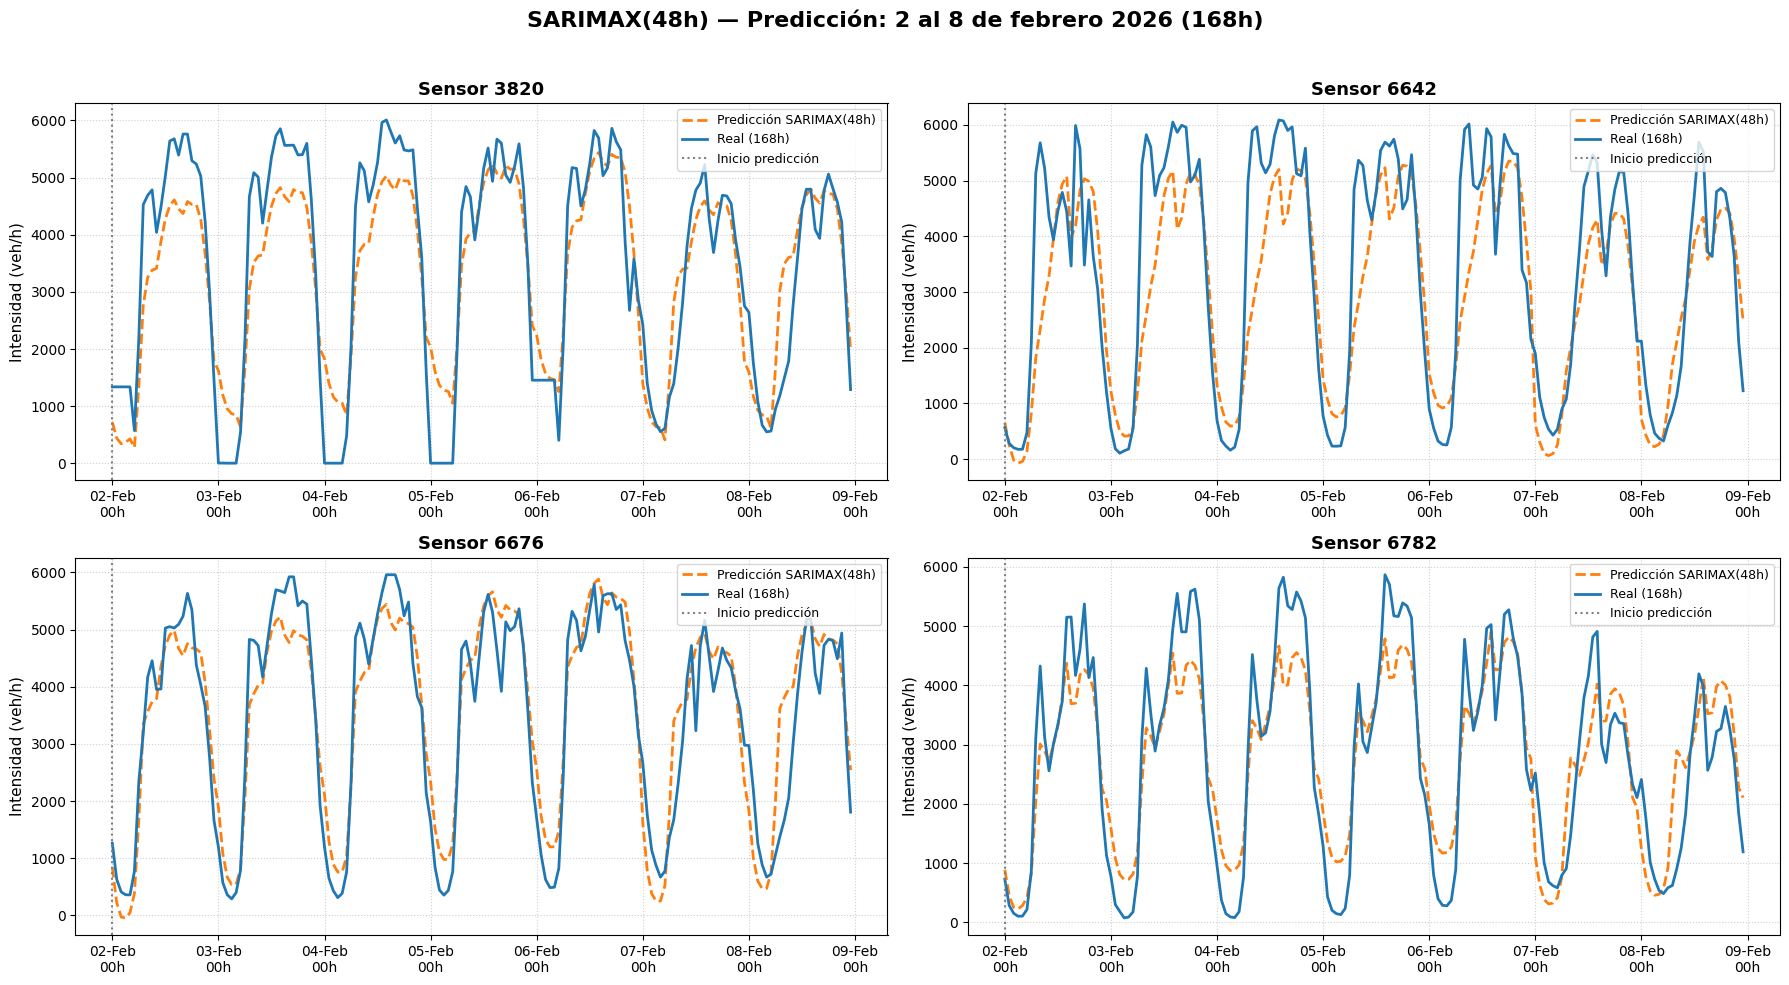

✅ Gráfica generada: SARIMAX(48h)


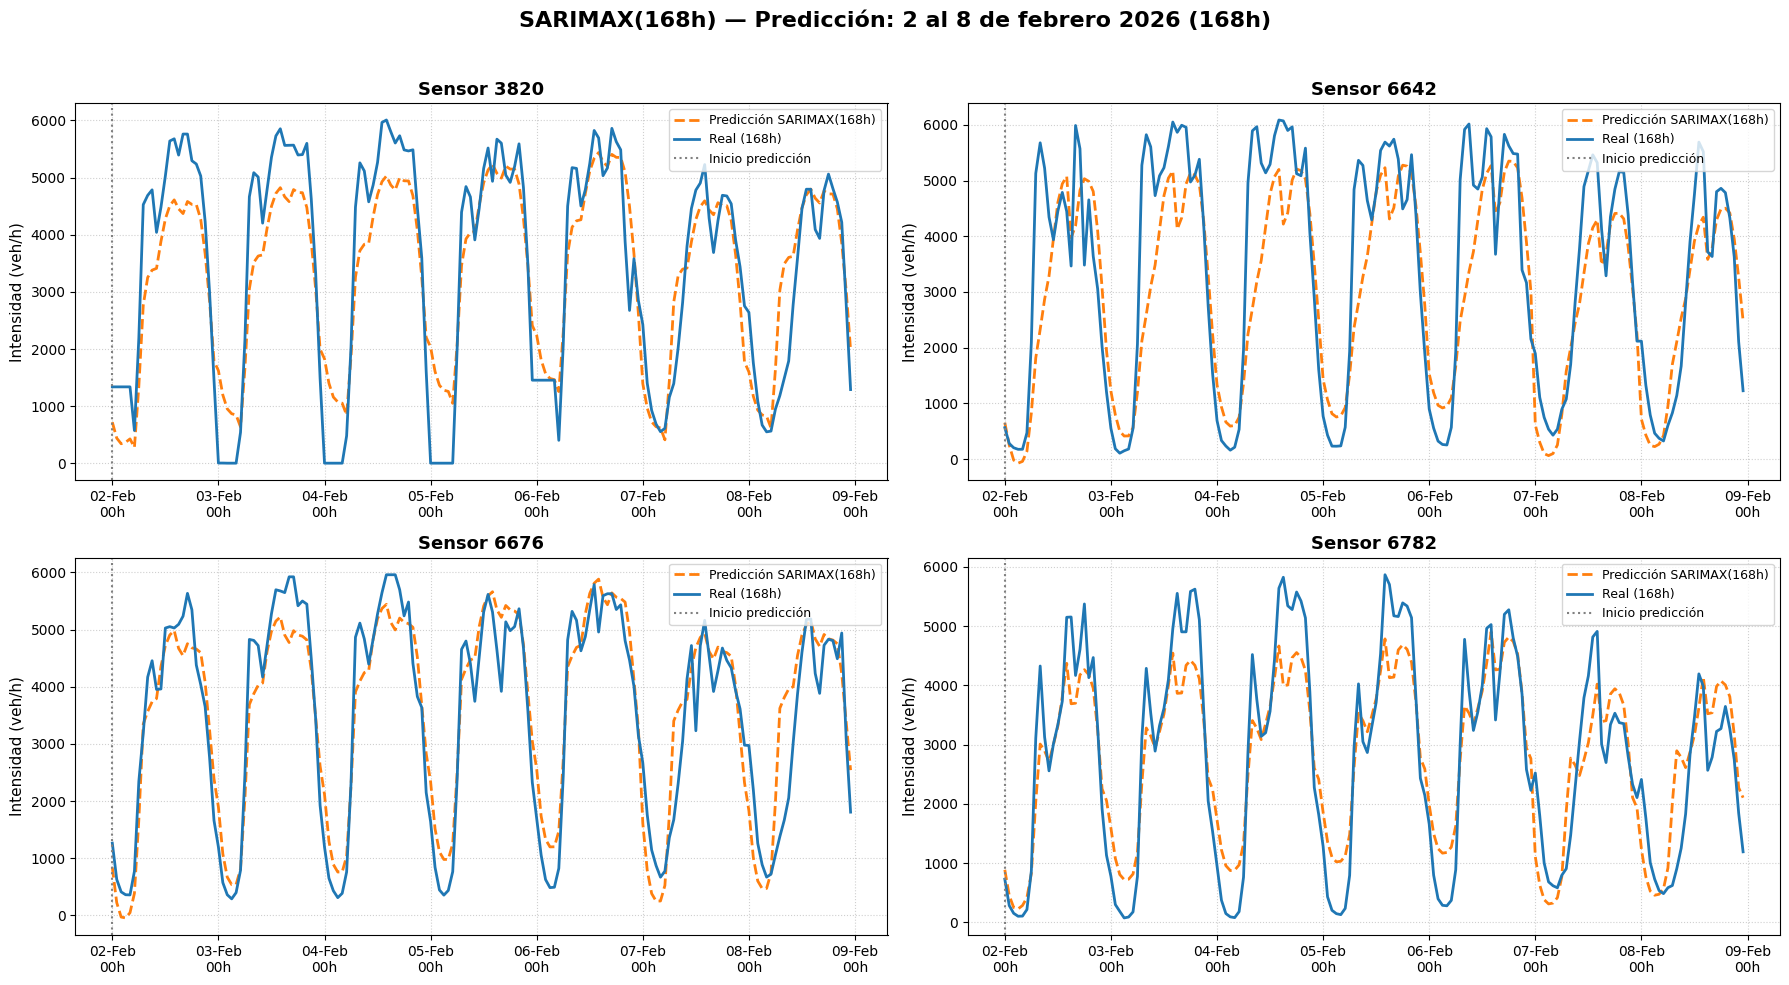

✅ Gráfica generada: SARIMAX(168h)


In [11]:
# ---------------------------------------------------------------------------
# 7. GRÁFICAS — Semana 2-8 febrero 2026 (Estilos TFM)
# ---------------------------------------------------------------------------
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

# 1. RECUPERAMOS TU FUNCIÓN DE GRAFICADO ORIGINAL (Estilos TFM)
def graficar_semana(df_pred_semana_48, df_pred_semana_168, real_semana, nombre_modelo_base):
    """Genera gráficas 2×2 para 48h y 168h según Estilos TFM."""
    semana_inicio = pd.Timestamp('2026-02-02 00:00:00')
    
    for lag, df_pred_semana in [('48', df_pred_semana_48), ('168', df_pred_semana_168)]:
        nombre_modelo = f'{nombre_modelo_base}({lag}h)'
        fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(18, 10))
        fig.suptitle(
            f'{nombre_modelo} — Predicción: 2 al 8 de febrero 2026 (168h)',
            fontsize=16, fontweight='bold', y=0.98
        )
        axes = axes.flatten()
        for i, col in enumerate(cols_intensidad):
            ax = axes[i]
            sensor_id = sensor_ids[i]
            ax.plot(
                df_pred_semana.index, df_pred_semana[col],
                color='#ff7f0e', linewidth=2, linestyle='--',
                label=f'Predicción {nombre_modelo}'
            )
            ax.plot(
                real_semana.index, real_semana[col],
                color='#1f77b4', linewidth=2, label='Real (168h)'
            )
            ax.axvline(
                x=semana_inicio, color='grey', linestyle=':',
                linewidth=1.5, label='Inicio predicción'
            )
            ax.set_title(f'Sensor {sensor_id}', fontsize=13, fontweight='bold')
            ax.set_ylabel('Intensidad (veh/h)', fontsize=11)
            ax.xaxis.set_major_formatter(mdates.DateFormatter('%d-%b\n%Hh'))
            ax.xaxis.set_major_locator(mdates.DayLocator())
            ax.grid(True, linestyle=':', alpha=0.6)
            ax.legend(loc='upper right', fontsize=9)
            ax.tick_params(axis='x', rotation=0)
        plt.tight_layout(rect=[0, 0, 1, 0.96])
        plt.show()
        print(f"✅ Gráfica generada: {nombre_modelo}")

# 2. FUNCIÓN PARA PREDICCIÓN ESTÁTICA DE LA SEMANA A VISUALIZAR
def predecir_semana_estatica(modelos, historico_df, df_futuro, cols_exog, cols_obj, steps=168):
    """Predicción a ciegas (sin rolling) para visualizar la degeneración del modelo a 7 días."""
    predicciones = {}
    exog_future = df_futuro[cols_exog].iloc[:steps]
    for col in cols_obj:
        modelo_actualizado = modelos[col].apply(
            endog=historico_df[col], exog=historico_df[cols_exog], refit=False
        )
        pred = modelo_actualizado.forecast(steps=steps, exog=exog_future)
        predicciones[col] = pred.values
    return pd.DataFrame(predicciones, index=df_futuro.index[:steps])

# 3. EJECUCIÓN
semana_inicio = pd.Timestamp('2026-02-02 00:00:00')
semana_fin    = pd.Timestamp('2026-02-08 23:00:00')

# Extraemos el histórico exacto antes de la semana a graficar
historico_grafica = pd.concat([df_train, df_val, df_test.loc[:semana_inicio].iloc[:-1]]).tail(504)
df_test_semana = df_test.loc[semana_inicio:semana_fin]

print("Generando predicciones para las gráficas...")
pred_semana_48  = predecir_semana_estatica(modelos_por_lag[48], historico_grafica, df_test_semana, cols_exogenas, cols_intensidad)
pred_semana_168 = predecir_semana_estatica(modelos_por_lag[168], historico_grafica, df_test_semana, cols_exogenas, cols_intensidad)

graficar_semana(pred_semana_48, pred_semana_168, df_test_semana[cols_intensidad], 'SARIMAX')

## 8. Exportación Excel Comparativo

In [12]:
import openpyxl
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
import os

def exportar_excel(resultados_test, nombre_modelo_base, color_48, color_168, ruta_excel):
    """Exporta el Excel comparativo 48h vs 168h según Estilos TFM."""
    os.makedirs(os.path.dirname(ruta_excel), exist_ok=True)
    
    horizontes_nombres = {1: '1_HORA', 24: '24_HORAS', 168: '168_HORAS'}
    horizontes_titulos = {1: '1 HORA', 24: '24 HORAS', 168: '168 HORAS'}
    
    def estilo_titulo(ws, fila, texto):
        ws.merge_cells(start_row=fila, start_column=1, end_row=fila, end_column=7)
        c = ws.cell(row=fila, column=1, value=texto)
        c.font      = Font(bold=True, color='FFFFFF', size=12)
        c.fill      = PatternFill('solid', fgColor='2F4F8F')
        c.alignment = Alignment(horizontal='center', vertical='center')

    def aplicar_borde(cell):
        thin = Side(style='thin')
        cell.border = Border(left=thin, right=thin, top=thin, bottom=thin)

    wb = openpyxl.Workbook()
    wb.remove(wb.active)

    for horizonte in [1, 24, 168]:
        nombre_hoja = horizontes_nombres[horizonte]
        titulo_hoja = horizontes_titulos[horizonte]
        ws = wb.create_sheet(title=nombre_hoja)

        anchos = [16, 12, 12, 12, 12, 12, 12]
        for i, ancho in enumerate(anchos, 1):
            ws.column_dimensions[openpyxl.utils.get_column_letter(i)].width = ancho

        estilo_titulo(ws, 1, f'HORIZONTE: {titulo_hoja} — {nombre_modelo_base}-48h vs {nombre_modelo_base}-168h')
        ws.row_dimensions[1].height = 22

        ws.merge_cells(start_row=2, start_column=2, end_row=2, end_column=4)
        ws.merge_cells(start_row=2, start_column=5, end_row=2, end_column=7)
        for col, texto, color in [(2, f'{nombre_modelo_base}-48h', color_48),
                                   (5, f'{nombre_modelo_base}-168h', color_168)]:
            c = ws.cell(row=2, column=col, value=texto)
            c.font      = Font(bold=True, color='FFFFFF', size=10)
            c.fill      = PatternFill('solid', fgColor=color)
            c.alignment = Alignment(horizontal='center', vertical='center')

        ws.cell(row=3, column=1, value='Sensor').font = Font(bold=True, color='FFFFFF', size=10)
        ws.cell(row=3, column=1).fill                 = PatternFill('solid', fgColor='4472C4')
        ws.cell(row=3, column=1).alignment            = Alignment(horizontal='center')
        for col, metrica in enumerate(['RMSE', 'MAE', 'R²', 'RMSE', 'MAE', 'R²'], 2):
            c = ws.cell(row=3, column=col, value=metrica)
            c.font      = Font(bold=True, color='FFFFFF', size=10)
            c.fill      = PatternFill('solid', fgColor='4472C4')
            c.alignment = Alignment(horizontal='center')

        colores_fila = ['FCE4D6', 'E2EFDA', 'FCE4D6', 'E2EFDA']
        for idx, sensor in enumerate(sensores):
            fila  = 4 + idx
            color = colores_fila[idx]
            m48   = resultados_test[(48,  horizonte)][sensor]
            m168  = resultados_test[(168, horizonte)][sensor]
            
            def fmt_r2(val):
                return round(val, 4) if val is not None else 'N/A'
            
            valores = [sensor,
                       round(m48['RMSE'], 2),  round(m48['MAE'], 2),  fmt_r2(m48['R²']),
                       round(m168['RMSE'], 2), round(m168['MAE'], 2), fmt_r2(m168['R²'])]
            for col, val in enumerate(valores, 1):
                c = ws.cell(row=fila, column=col, value=val)
                c.fill      = PatternFill('solid', fgColor=color)
                c.font      = Font(size=10)
                c.alignment = Alignment(horizontal='center')
                aplicar_borde(c)

        fila_prom = 8
        ws.cell(row=fila_prom, column=1, value='PROMEDIO')
        
        def prom_r2(lag, h):
            vals = [resultados_test[(lag, h)][s]['R²'] for s in sensores if resultados_test[(lag, h)][s]['R²'] is not None]
            return round(sum(vals)/len(vals), 4) if vals else 'N/A'
        
        promedios = [
            round(np.mean([resultados_test[(48,  horizonte)][s]['RMSE'] for s in sensores]), 2),
            round(np.mean([resultados_test[(48,  horizonte)][s]['MAE']  for s in sensores]), 2),
            prom_r2(48, horizonte),
            round(np.mean([resultados_test[(168, horizonte)][s]['RMSE'] for s in sensores]), 2),
            round(np.mean([resultados_test[(168, horizonte)][s]['MAE']  for s in sensores]), 2),
            prom_r2(168, horizonte),
        ]
        for col, val in enumerate([None] + promedios, 1):
            c = ws.cell(row=fila_prom, column=col)
            if col > 1:
                c.value = val
            c.font      = Font(bold=True, size=10)
            c.fill      = PatternFill('solid', fgColor='D9E1F2')
            c.alignment = Alignment(horizontal='center')
            aplicar_borde(c)

    wb.save(ruta_excel)
    print(f"✅ Excel guardado en: {ruta_excel}")


In [13]:
ruta_excel = '../../data/processed/models/1.SARIMAX/comparativa_SARIMAX48_vs_SARIMAX168_v02.xlsx'
exportar_excel(
    resultados_test,
    nombre_modelo_base='SARIMAX',
    color_48='C55A11',   # naranja oscuro
    color_168='375623',  # verde oscuro
    ruta_excel=ruta_excel
)


✅ Excel guardado en: ../../data/processed/models/1.SARIMAX/comparativa_SARIMAX48_vs_SARIMAX168_v02.xlsx
